In [ ]:
regresion_clima.ipynb

In [2]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor y modelos del proyecto
from scripts.database import engine
from scripts.models import Pais, DatosPais, MetricasETL

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       2.4.3
   seaborn     0.13.2
   statsmodels 0.14.4


In [3]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    p.nombre_comun,
    p.nombre_oficial,
    p.capital,
    p.region,
    p.subregion,
    d.poblacion,
    d.area_km2,
    d.latitud,
    d.longitud,
    d.continentes,
    d.fecha_extraccion
FROM datos_paises d
JOIN paises p ON d.pais_id = p.id
ORDER BY d.fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print("\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 2,069
   Columnas : 11

📋 Primeras filas:


,nombre_comun,nombre_oficial,capital,region,subregion,poblacion,area_km2,latitud,longitud,continentes,fecha_extraccion
0,Norte Bosqueland 648,Estado de Norte Bosqueland 648,Altavista,Asia,Eastern Asia,214509641,15878973.37,50.5243,109.5778,Asia,2025-12-16 17:15:48.946832
1,Lago Claridad 40,Reino de Lago Claridad 40,Altavista,Africa,Northern Africa,6661789,3885761.58,13.6023,46.8371,Africa,2025-12-16 17:24:40.941045
2,Isla Lunaria 770,Estado de Isla Lunaria 770,Villa Norte,Americas,Caribbean,51660444,3215144.79,-29.3930,-69.6842,America,2025-12-16 18:17:24.948051
3,Costa Terranova 32,Federación de Costa Terranova 32,Río Blanco,Americas,North America,236407726,2214299.75,60.3611,-152.0686,America,2025-12-16 19:03:13.940971
4,Isla Libertad 77,Reino de Isla Libertad 77,Villa Norte,Americas,North America,72524334,16223801.61,46.5863,-71.3108,America,2025-12-16 19:31:28.941389


In [4]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)

print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print("\n🌍 Países en el dataset:")
print(df['nombre_comun'].value_counts())

print("\n🌐 Regiones:")
print(df['region'].value_counts())

print("\n🗺️ Continentes:")
print(df['continentes'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2069 entries, 0 to 2068
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   nombre_comun      2069 non-null   object        
 1   nombre_oficial    2069 non-null   object        
 2   capital           2069 non-null   object        
 3   region            2069 non-null   object        
 4   subregion         2069 non-null   object        
 5   poblacion         2069 non-null   int64         
 6   area_km2          2069 non-null   float64       
 7   latitud           2069 non-null   float64       
 8   longitud          2069 non-null   float64       
 9   continentes       2069 non-null   object        
 10  fecha_extraccion  2069 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 177.9+ KB
None

📊 Valores nulos por columna:
nombre_comun        0
nombre_oficial   

In [5]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_num = ['poblacion', 'area_km2', 'latitud', 'longitud']

desc = df[vars_num].describe().round(2)

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
          poblacion     area_km2  latitud  longitud
count  2.069000e+03      2069.00  2069.00   2069.00
mean   1.018723e+08   6805673.68    15.03     30.87
std    9.867980e+07   5643784.44    33.21     85.81
min    0.000000e+00         0.49   -90.00   -176.20
25%    2.073426e+07   1014037.26   -11.88    -13.00
50%    8.828392e+07   6408020.80    14.76     28.81
75%    1.688507e+08  11718410.97    42.88    105.00
max    1.417492e+09  17491315.08    79.98    179.93


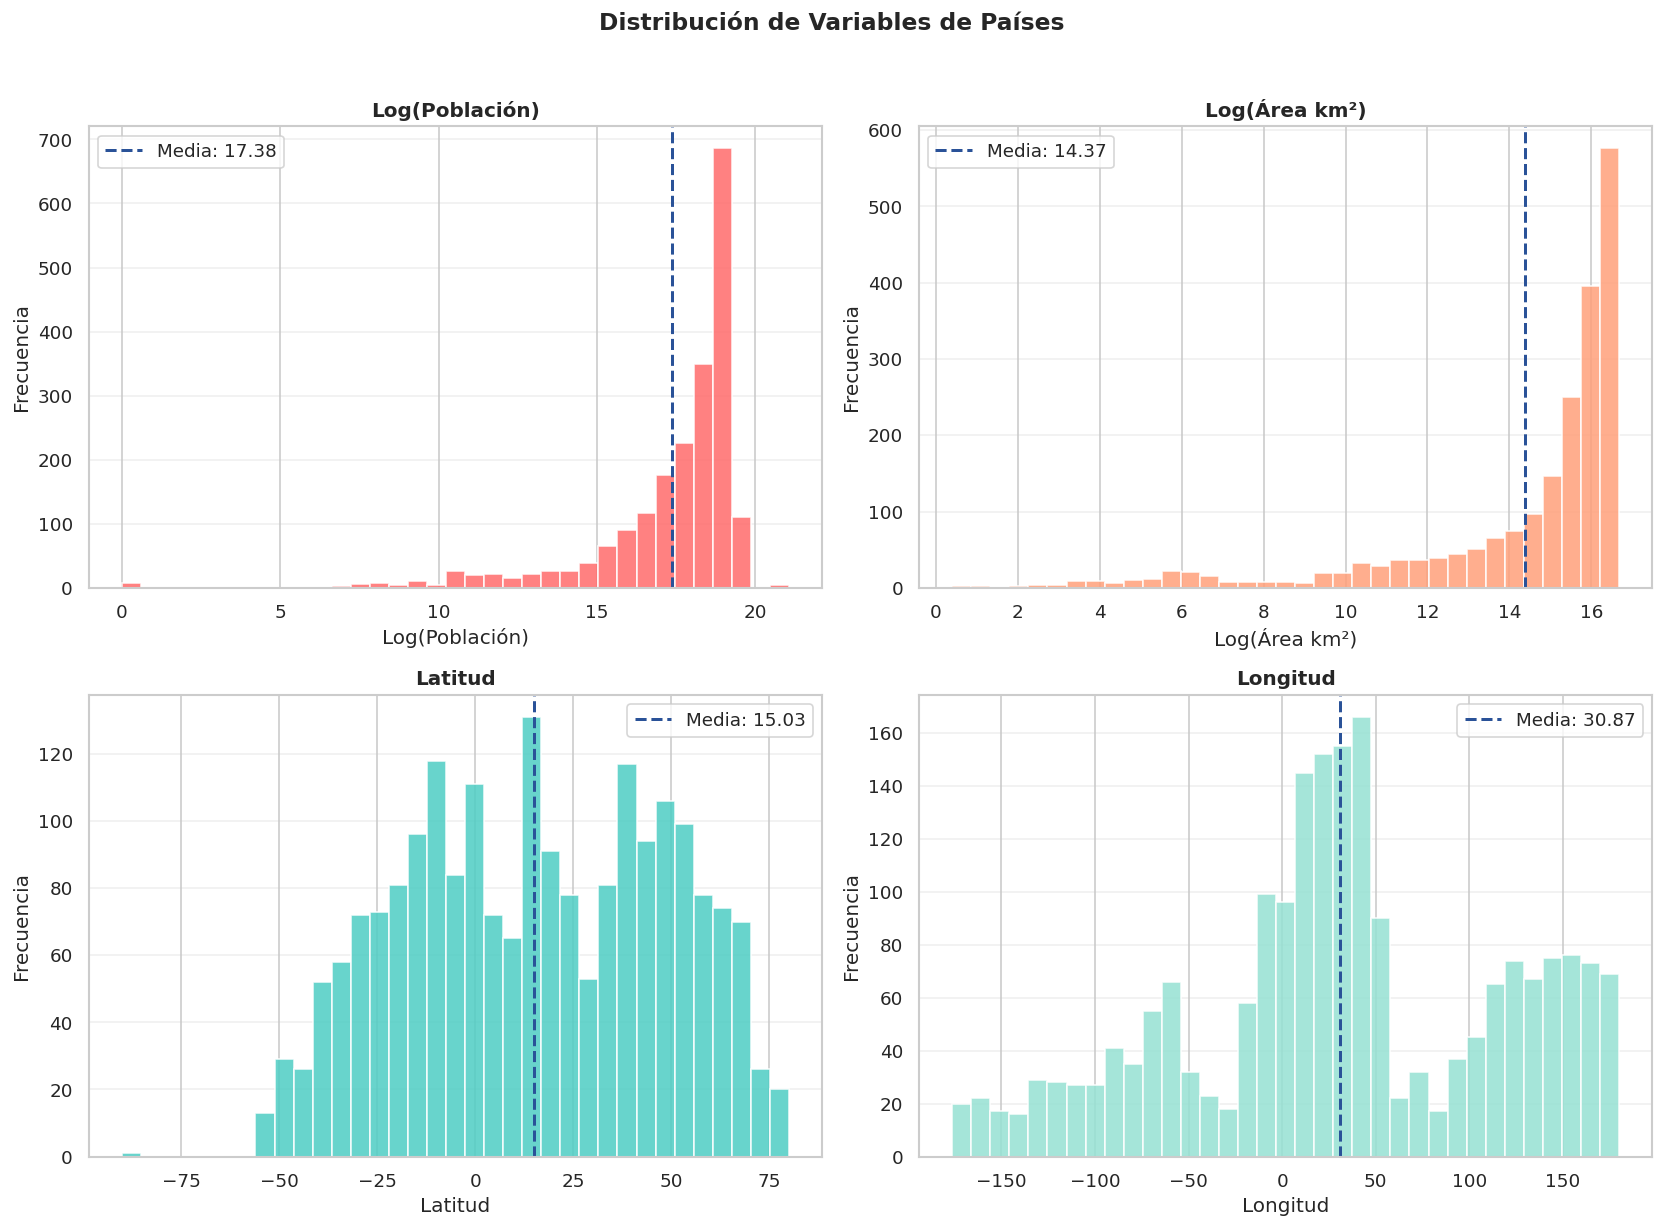

In [18]:
# ── CELDA 5: Crear variables log + histogramas ───────────────
os.makedirs("../data/graficas", exist_ok=True)

# Crear columnas log en el DataFrame principal
df['poblacion_log'] = np.log1p(df['poblacion'])
df['area_log'] = np.log1p(df['area_km2'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables de Países',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'poblacion_log': ('Log(Población)', '#ff6b6b'),
    'area_log': ('Log(Área km²)', '#ffa07a'),
    'latitud': ('Latitud', '#4ecdc4'),
    'longitud': ('Longitud', '#95e1d3'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    serie = df[col].dropna()

    ax.hist(serie, bins=35, color=color, edgecolor='white', alpha=0.85)
    media = serie.mean()

    ax.axvline(
        media,
        color='#2a5298',
        linestyle='--',
        linewidth=1.8,
        label=f'Media: {media:,.2f}'
    )

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones_paises.png',
            dpi=150, bbox_inches='tight')
plt.show()

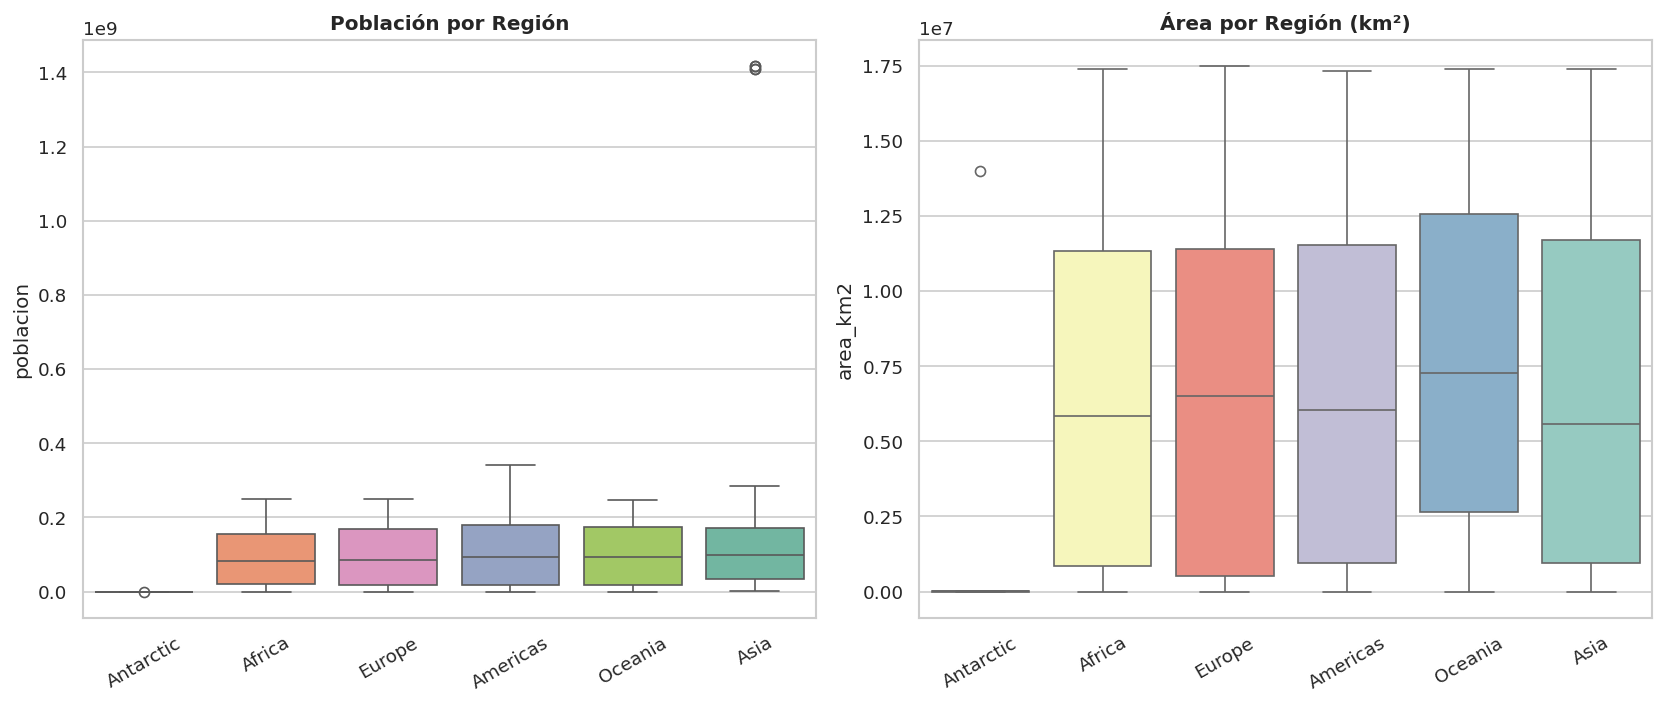

In [19]:
# ── CELDA 6: Boxplots por región ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden = df.groupby('region')['poblacion'].median().sort_values().index

sns.boxplot(
    data=df,
    x='region',
    y='poblacion',
    hue='region',
    order=orden,
    palette='Set2',
    ax=axes[0],
    legend=False
)
axes[0].set_title('Población por Región', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=df,
    x='region',
    y='area_km2',
    hue='region',
    order=orden,
    palette='Set3',
    ax=axes[1],
    legend=False
)
axes[1].set_title('Área por Región (km²)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots_region.png',
            dpi=150, bbox_inches='tight')
plt.show()

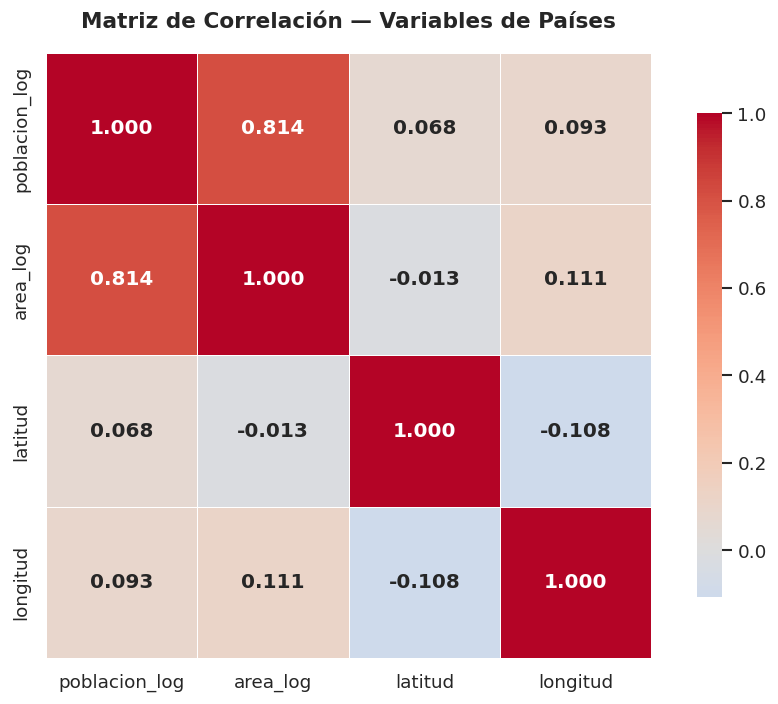

In [20]:
# ── CELDA 7: Matriz de correlación ───────────────────────────
vars_num = ['poblacion_log', 'area_log', 'latitud', 'longitud']

corr = df[vars_num].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 12, 'weight': 'bold'}
)

plt.title(
    'Matriz de Correlación — Variables de Países',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion_paises.png',
            dpi=150, bbox_inches='tight')
plt.show()

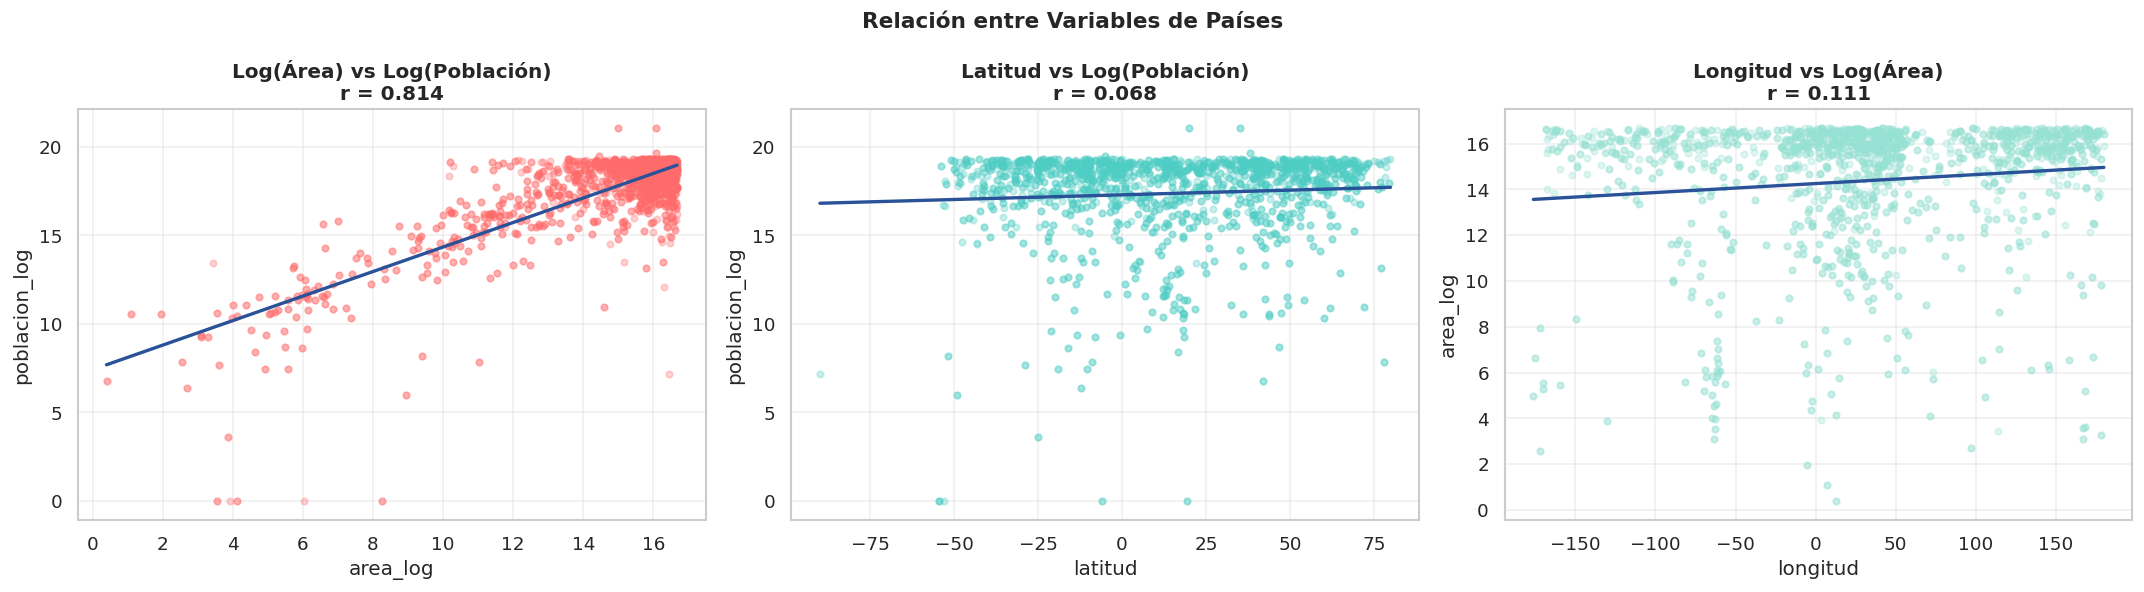

In [21]:
# ── CELDA 8: Scatter plots entre variables de países ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación entre Variables de Países',
             fontsize=13, fontweight='bold')

pares = [
    ('area_log', 'poblacion_log', 'Log(Área) vs Log(Población)', '#ff6b6b'),
    ('latitud', 'poblacion_log', 'Latitud vs Log(Población)', '#4ecdc4'),
    ('longitud', 'area_log', 'Longitud vs Log(Área)', '#95e1d3'),
]

for ax, (x_var, y_var, titulo, color) in zip(axes, pares):
    x = df[x_var]
    y = df[y_var]

    ax.scatter(x, y, alpha=0.3, s=15, color=color)

    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    xp = np.linspace(x.min(), x.max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)

    r = df[[x_var, y_var]].corr().iloc[0, 1]

    ax.set_title(f'{titulo}\nr = {r:.3f}', fontweight='bold')
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter_paises.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── CELDA 9: Split Train / Test ──────────────────────────────
X = df[['area_log', 'latitud', 'longitud']].values
y = df['poblacion_log'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 1,655 muestras (80%)
Test : 414 muestras (20%)


In [23]:
# ── CELDA 10: Entrenamiento con múltiples variables ──────────
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print(f"Intercepto β₀: {modelo.intercept_:.4f}")

for i, coef in enumerate(modelo.coef_):
    print(f"Coeficiente β{i+1}: {coef:.4f}")

print("\nEcuación:")
print("log(poblacion) = β₀ + β₁·area_log + β₂·latitud + β₃·longitud")

Intercepto β₀: 7.1858
Coeficiente β1: 0.7009
Coeficiente β2: 0.0071
Coeficiente β3: 0.0003

Ecuación:
log(poblacion) = β₀ + β₁·area_log + β₂·latitud + β₃·longitud


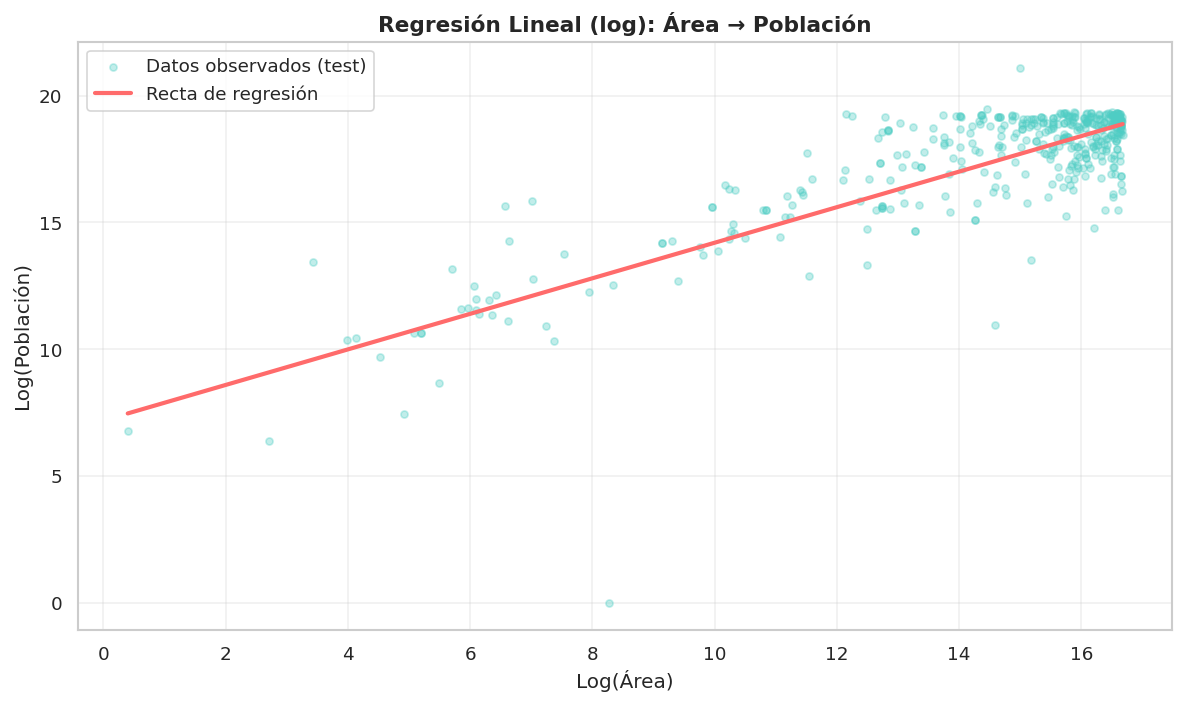

In [24]:
# ── CELDA 11: Regresión con log ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    X_test[:, 0],
    y_test,
    alpha=0.35,
    s=18,
    color='#4ecdc4',
    label='Datos observados (test)'
)

x_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 300)
y_line = modelo.predict(
    np.column_stack([x_line, np.zeros_like(x_line), np.zeros_like(x_line)])
)

ax.plot(
    x_line,
    y_line,
    color='#ff6b6b',
    linewidth=2.5,
    label='Recta de regresión'
)

ax.set_xlabel('Log(Área)', fontsize=12)
ax.set_ylabel('Log(Población)', fontsize=12)
ax.set_title('Regresión Lineal (log): Área → Población',
             fontsize=13, fontweight='bold')

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_log_paises.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ── CELDA 12: Métricas del modelo ────────────────────────────
r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("   MÉTRICAS — REGRESIÓN LOG(Población) vs LOG(Área)")
print("=" * 50)
print(f"  R²   (coef. determinación)   : {r2:.4f} ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático medio): {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 50)


   MÉTRICAS — REGRESIÓN LOG(Población) vs LOG(Área)
  R²   (coef. determinación)   : 0.6639 (66.39%)
  MSE  (error cuadrático medio): 2.0022
  RMSE (raíz del MSE)          : 1.4150
  MAE  (error absoluto medio)  : 0.9752


In [28]:
# ── CELDA 13: OLS con log ────────────────────────────────────
X_ols = df[['area_log', 'latitud', 'longitud']]
X_ols = sm.add_constant(X_ols)

modelo_ols = sm.OLS(df['poblacion_log'], X_ols).fit()

print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          poblacion_log   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     1389.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:05:30   Log-Likelihood:                -3750.1
No. Observations:                2069   AIC:                             7508.
Df Residuals:                    2065   BIC:                             7531.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3132      0.159     45.877      0.0

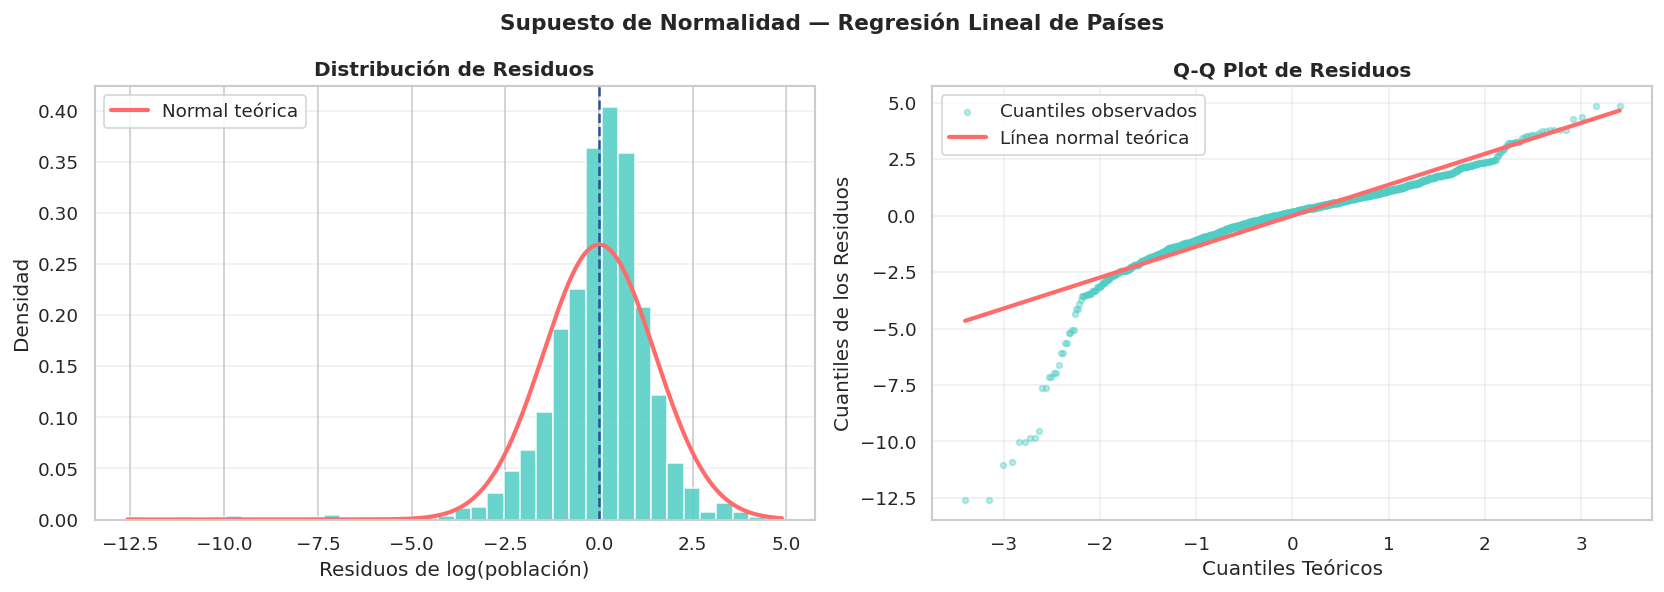


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.8521
   p-value       : 0.000000
   Conclusión    : ⚠️ Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot


In [29]:
# ── CELDA 14: Normalidad de residuos  ────────

# Residuos sobre todo el dataset
y_pred_all = modelo.predict(X)
residuos = y - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal de Países',
             fontsize=13, fontweight='bold')

# Histograma con curva normal superpuesta
axes[0].hist(
    residuos,
    bins=40,
    color='#4ecdc4',
    edgecolor='white',
    density=True,
    alpha=0.85
)

xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    color='#ff6b6b',
    linewidth=2.5,
    label='Normal teórica'
)

axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos de log(población)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')

axes[1].scatter(
    osm,
    osr,
    alpha=0.4,
    s=12,
    color='#4ecdc4',
    label='Cuantiles observados'
)

axes[1].plot(
    osm,
    slope * np.array(osm) + intercept,
    color='#ff6b6b',
    linewidth=2.5,
    label='Línea normal teórica'
)

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_residuos_paises.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Shapiro-Wilk (máximo 5000 muestras)
muestra_sw = (
    residuos if len(residuos) <= 5000
    else np.random.default_rng(42).choice(residuos, 5000, replace=False)
)

stat_sw, p_sw = stats.shapiro(muestra_sw)

print("\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")

if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️ Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot")

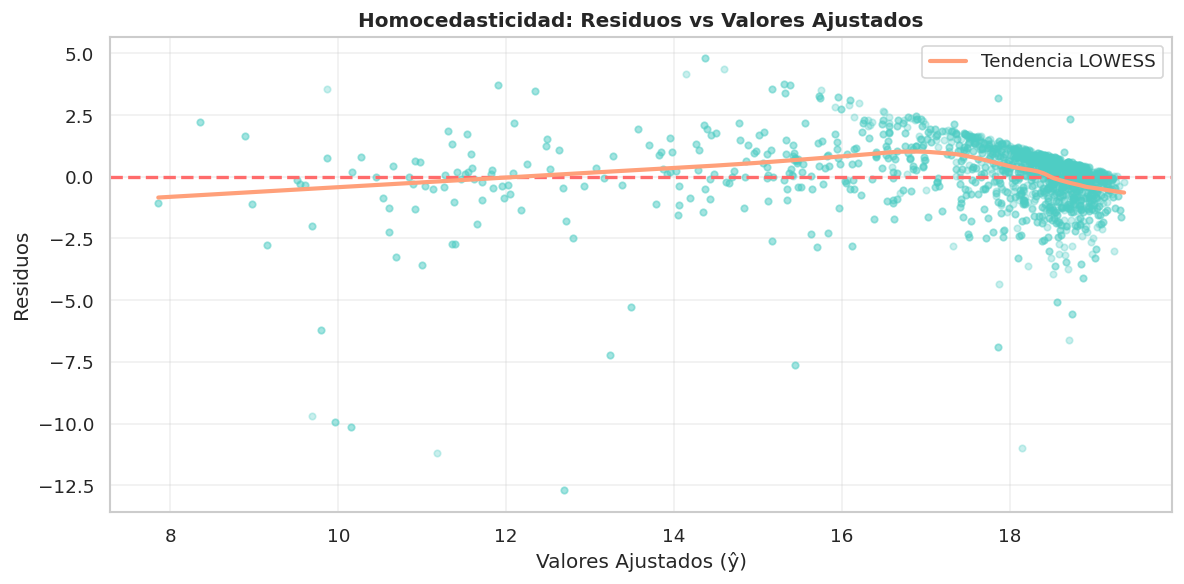


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 122.1433
   p-value        : 0.000000
   Conclusión     : ⚠️ Heterocedasticidad detectada (p ≤ 0.05)


In [30]:
# ── CELDA 15: Homocedasticidad (modelo OLS con log) ──────────
residuos_ols  = modelo_ols.resid
ajustados_ols = modelo_ols.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# Línea de tendencia suavizada LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(
    lowess[:, 0],
    lowess[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='Tendencia LOWESS'
)

plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title(
    'Homocedasticidad: Residuos vs Valores Ajustados',
    fontsize=12,
    fontweight='bold'
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homocedasticidad_paises.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols.model.exog
)

print("\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️ Heterocedasticidad detectada (p ≤ 0.05)")

In [31]:
# ── CELDA 16: Modelo múltiple (versión final) ────────────────

FEATURES = ['area_log', 'latitud', 'longitud']

X_multi = df[FEATURES].values
y_multi = df['poblacion_log'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto β₀: {modelo_multi.intercept_:.4f}")

for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>12}: {coef:.4f}")

Intercepto β₀: 7.1858
Coeficiente     area_log: 0.7009
Coeficiente      latitud: 0.0071
Coeficiente     longitud: 0.0003


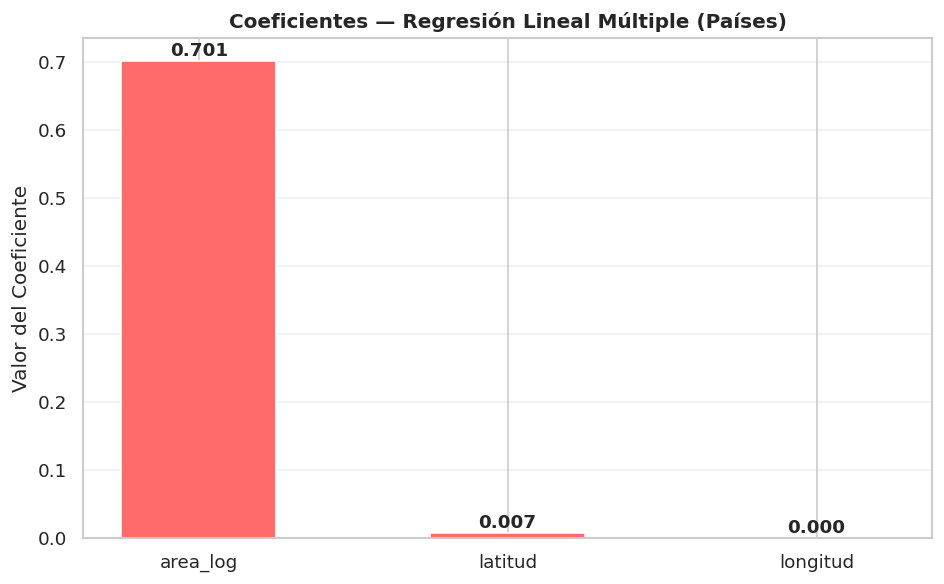

In [32]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────

FEATURES = ['area_log', 'latitud', 'longitud']

coeficientes = modelo.coef_

colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in coeficientes]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    FEATURES,
    coeficientes,
    color=colores,
    edgecolor='white',
    width=0.5
)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title(
    'Coeficientes — Regresión Lineal Múltiple (Países)',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, coeficientes):
    offset = 0.002 if coef >= 0 else -0.005
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f'{coef:.3f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_paises.png',
            dpi=150,
            bbox_inches='tight'
)

plt.show()

In [33]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────

r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 50)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE (PAÍSES)")
print("=" * 50)
print(f"  R²   (coef. determinación)   : {r2_m:.4f} ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático medio): {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae_m:.4f}")
print("=" * 50)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE (PAÍSES)
  R²   (coef. determinación)   : 0.6639 (66.39%)
  MSE  (error cuadrático medio): 2.0022
  RMSE (raíz del MSE)          : 1.4150
  MAE  (error absoluto medio)  : 0.9752


In [34]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────
FEATURES = ['area_log', 'latitud', 'longitud']

X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['poblacion_log'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:          poblacion_log   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     1389.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:39:51   Log-Likelihood:                -3750.1
No. Observations:                2069   AIC:                             7508.
Df Residuals:                    2065   BIC:                             7531.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3132      0.159     45.877      0.0

In [35]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────

FEATURES = ['area_log', 'latitud', 'longitud']

X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data["VIF"] = vif_data["VIF"].round(3)

vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
    if v < 5 else (
        "⚠️ Moderada (5 ≤ VIF < 10)"
        if v < 10 else
        "❌ Severa (VIF ≥ 10)"
    )
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
Variable   VIF                          Criterio
area_log 1.375 ✅ Sin multicolinealidad (VIF < 5)
 latitud 1.206 ✅ Sin multicolinealidad (VIF < 5)
longitud 1.156 ✅ Sin multicolinealidad (VIF < 5)


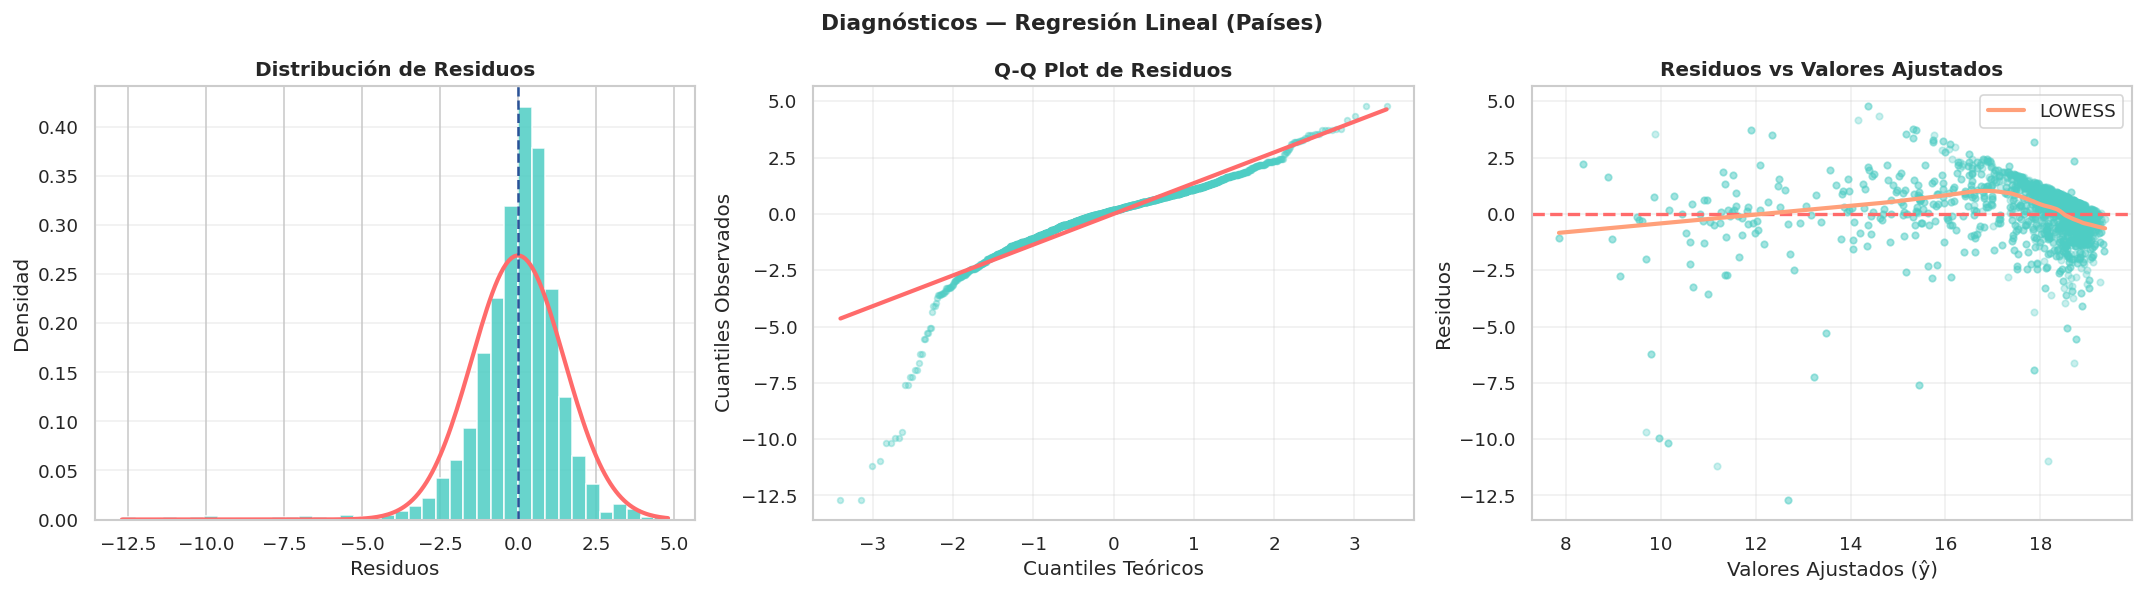


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.000000 → ⚠️ Se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.000000 → ⚠️ Heterocedasticidad detectada


In [36]:
# ── CELDA 21: Diagnósticos completos — modelo OLS ────────────

residuos_m  = modelo_ols.resid.values
ajustados_m = modelo_ols.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal (Países)',
             fontsize=13, fontweight='bold')

# ── Histograma de residuos
axes[0].hist(
    residuos_m,
    bins=40,
    color='#4ecdc4',
    edgecolor='white',
    density=True,
    alpha=0.85
)

xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
    color='#ff6b6b',
    linewidth=2.5
)

axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')

axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(
    osm,
    s * np.array(osm) + i,
    color='#ff6b6b',
    linewidth=2.5
)

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(
    ajustados_m,
    residuos_m,
    alpha=0.30,
    s=15,
    color='#4ecdc4'
)

axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(
    lowess_m[:, 0],
    lowess_m[:, 1],
    color='#ffa07a',
    linewidth=2.5,
    label='LOWESS'
)

axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_paises.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tests estadísticos
muestra_m = (
    residuos_m if len(residuos_m) <= 5000
    else np.random.default_rng(42).choice(residuos_m, 5000, replace=False)
)

stat_sw_m, p_sw_m = stats.shapiro(muestra_m)

lm_m, lm_p_m, _, _ = het_breuschpagan(
    modelo_ols.resid,
    modelo_ols.model.exog
)

print("\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️ Se rechaza normalidad'}")

print("\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️ Heterocedasticidad detectada'}")

In [37]:
# ── CELDA 22: Resumen final del modelo ───────────────────────

resumen = pd.DataFrame({
    'Modelo'   : ['Regresión Lineal Múltiple'],
    'Variables': ['area_log + latitud + longitud'],
    'R²'       : [round(r2, 4)],
    'R² Aj.'   : [round(modelo_ols.rsquared_adj, 4)],
    'RMSE'     : [round(rmse, 4)],
    'MAE'      : [round(mae, 4)],
    'AIC'      : [round(modelo_ols.aic, 2)],
    'BIC'      : [round(modelo_ols.bic, 2)],
})

print("=" * 80)
print("              RESUMEN DEL MODELO FINAL")
print("=" * 80)
print(resumen.to_string(index=False))
print("=" * 80)

              RESUMEN DEL MODELO FINAL
                   Modelo                     Variables     R²  R² Aj.  RMSE    MAE     AIC     BIC
Regresión Lineal Múltiple area_log + latitud + longitud 0.6639  0.6682 1.415 0.9752 7508.11 7530.65


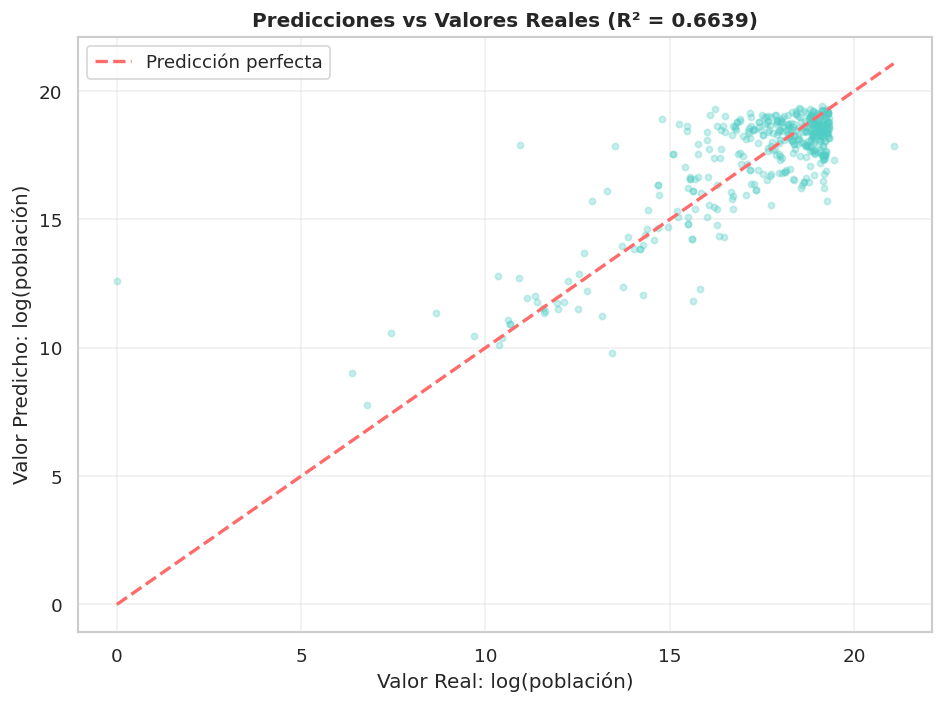

In [38]:
# ── CELDA 23: Predicciones vs Valores Reales — modelo final ──
fig, ax = plt.subplots(figsize=(8, 6))

minval = min(y_test.min(), y_pred.min())
maxval = max(y_test.max(), y_pred.max())

ax.scatter(
    y_test,
    y_pred,
    alpha=0.30,
    s=14,
    color='#4ecdc4'
)

ax.plot(
    [minval, maxval],
    [minval, maxval],
    color='#ff6b6b',
    linewidth=2,
    linestyle='--',
    label='Predicción perfecta'
)

r2_val = r2_score(y_test, y_pred)

ax.set_title(f'Predicciones vs Valores Reales (R² = {r2_val:.4f})',
             fontweight='bold')

ax.set_xlabel('Valor Real: log(población)')
ax.set_ylabel('Valor Predicho: log(población)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales_paises.png',
            dpi=150, bbox_inches='tight')
plt.show()